# Import Libraries
In this step, we import the necessary libraries for deep learning (PyTorch), data handling (Pandas, NumPy), 
and visualization (Matplotlib). These libraries help us process data, train the model, and visualize results.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Load the Dataset
We load the `synthetic_real_estate_data.csv` file, which contains real estate transaction data along with 
macroeconomic indicators such as interest rates, GDP growth, and unemployment rates.


In [2]:
df = pd.read_csv("synthetic_real_estate_data.csv")
df.head()  # Display first 5 rows to confirm data is loaded correctly


,interest_rate,inflation_rate,gdp_growth,unemployment_rate,real_estate_prices,household_income,sp500_index,transaction_volume
0,2.998160,4.210158,-1.278133,4.182545,164.868636,54810.634307,4516.526392,5888.344746
1,5.302857,1.420700,4.317870,4.950132,98.304685,83352.075790,3049.173833,7627.949294
2,4.427976,1.808144,1.536767,4.239073,149.154603,109835.666870,3044.247103,8770.555916
3,3.894634,5.492771,3.785202,3.620918,152.805806,98577.990913,3647.220438,9389.761753
4,2.124075,4.032145,0.240347,3.844451,130.895681,104524.891829,3977.286381,9136.811090


# Define Features and Target
We select relevant macroeconomic indicators as input features. 
The target variable is `transaction_volume`, which represents the number of real estate transactions.


In [3]:
features = ["interest_rate", "inflation_rate", "gdp_growth", "unemployment_rate",
            "real_estate_prices", "household_income", "sp500_index"]
target = "transaction_volume"

X = df[features].values
y = df[target].values.reshape(-1, 1)  # Reshape to ensure correct format


# Normalize Data
Neural networks perform better with scaled data, so we use StandardScaler to normalize both input features and the target variable.


In [4]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)  # Normalize target variable


# Split Data into Training and Testing Sets
We split the dataset into 80% training and 20% testing. The training set is used for learning, while the test set evaluates accuracy.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Convert Data to PyTorch Tensors
Since we are using PyTorch, we convert the NumPy arrays into PyTorch tensors to make them compatible with our model.


In [6]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# Define the Neural Network Model
This model consists of multiple layers with ReLU activation functions and batch normalization for stability.


In [7]:
class REITForecaster(nn.Module):
    def __init__(self, input_size):
        super(REITForecaster, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Initialize model
model = REITForecaster(input_size=len(features))


# Define Loss Function and Optimizer
We use Mean Squared Error (MSE) as the loss function and the Adam optimizer with a learning rate of 0.001.


In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Train the Model
We train the model for 20 epochs, recording the loss after each epoch.


In [9]:
epochs = 20
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [1/20], Loss: 1.2108
Epoch [2/20], Loss: 1.0717
Epoch [3/20], Loss: 0.9485
Epoch [4/20], Loss: 0.8403
Epoch [5/20], Loss: 0.7442
Epoch [6/20], Loss: 0.6589
Epoch [7/20], Loss: 0.5810
Epoch [8/20], Loss: 0.5106
Epoch [9/20], Loss: 0.4452
Epoch [10/20], Loss: 0.3834
Epoch [11/20], Loss: 0.3255
Epoch [12/20], Loss: 0.2712
Epoch [13/20], Loss: 0.2215
Epoch [14/20], Loss: 0.1775
Epoch [15/20], Loss: 0.1394
Epoch [16/20], Loss: 0.1078
Epoch [17/20], Loss: 0.0827
Epoch [18/20], Loss: 0.0642
Epoch [19/20], Loss: 0.0522
Epoch [20/20], Loss: 0.0458


# Evaluate the Model
After training, we use the test set to see how well the model generalizes.


In [10]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)

# Convert predictions and actual values back to original scale
predictions_np = scaler_y.inverse_transform(predictions.numpy())
y_test_np = scaler_y.inverse_transform(y_test_tensor.numpy())

# Calculate RMSE
rmse = np.sqrt(np.mean((predictions_np - y_test_np) ** 2))
print(f"RMSE: {rmse:.4f}")


RMSE: 416.5607


# Plot Training Loss
We visualize the decrease in loss over the training epochs.


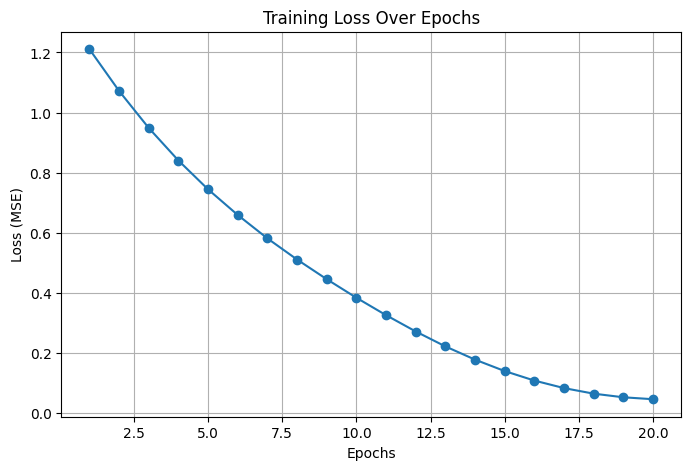

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()


# Predicted vs Actual Values
We compare predicted transaction volumes with actual values.


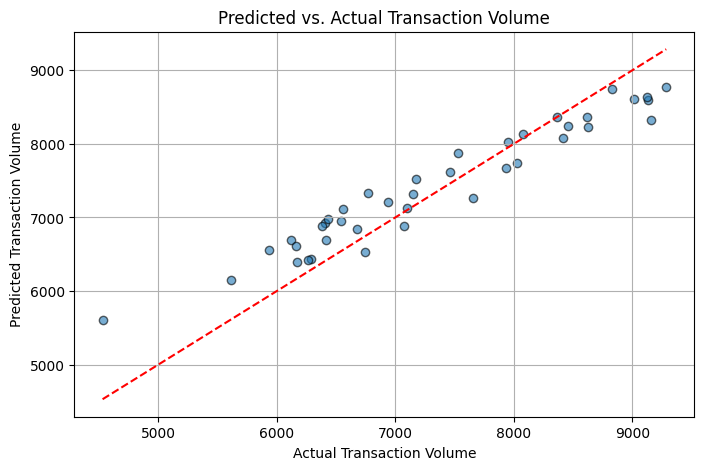

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_np, predictions_np, alpha=0.6, edgecolors="k")
plt.xlabel("Actual Transaction Volume")
plt.ylabel("Predicted Transaction Volume")
plt.title("Predicted vs. Actual Transaction Volume")
plt.plot([min(y_test_np), max(y_test_np)], [min(y_test_np), max(y_test_np)], color='red', linestyle='dashed')
plt.grid(True)
plt.show()
